In [6]:
# Install TensorFlow first (uncomment and run this line)
!pip install tensorflow

# After installation, restart your kernel and then run the imports:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

In [7]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training samples:", x_train.shape)
print("Testing samples:", x_test.shape)

Training samples: (60000, 28, 28)
Testing samples: (10000, 28, 28)


In [8]:
def create_model():
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [9]:
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "RMSProp": RMSprop(learning_rate=0.001),
    "Adam": Adam(learning_rate=0.001)
}

In [10]:
histories = {}

for name, optimizer in optimizers.items():

    print(f"\nTraining using {name}")

    model = create_model()

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_data=(x_test, y_test),
        verbose=1
    )

    histories[name] = history


Training using SGD


C:\Users\Yogeshram\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8315 - loss: 0.6399 - val_accuracy: 0.9116 - val_loss: 0.3117
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9164 - loss: 0.2916 - val_accuracy: 0.9254 - val_loss: 0.2558
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9315 - loss: 0.2392 - val_accuracy: 0.9367 - val_loss: 0.2164
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9406 - loss: 0.2053 - val_accuracy: 0.9450 - val_loss: 0.1894
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9479 - loss: 0.1803 - val_accuracy: 0.9499 - val_loss: 0.1730
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9529 - loss: 0.1612 - val_accuracy: 0.9524 - val_loss: 0.1603
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9574 - loss: 0.1456 - val_accuracy: 0.9549 - val_loss: 0.1491
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9614 - loss: 0.132

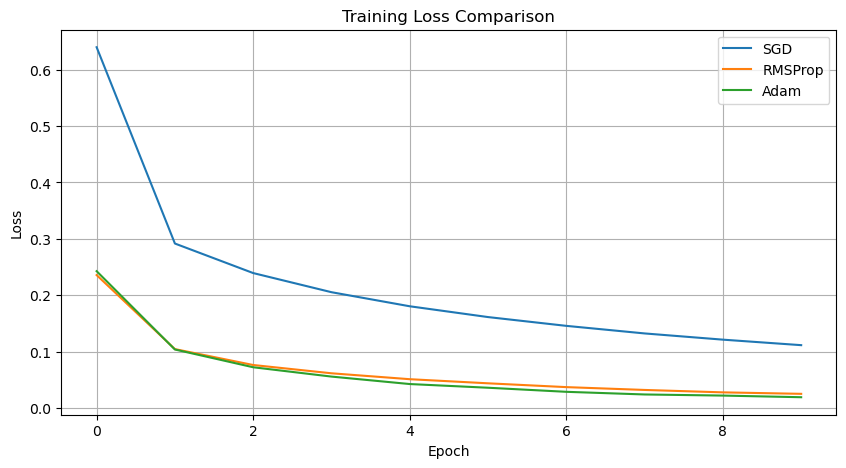

In [11]:
plt.figure(figsize=(10,5))

for name, history in histories.items():
    plt.plot(history.history['loss'], label=name)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

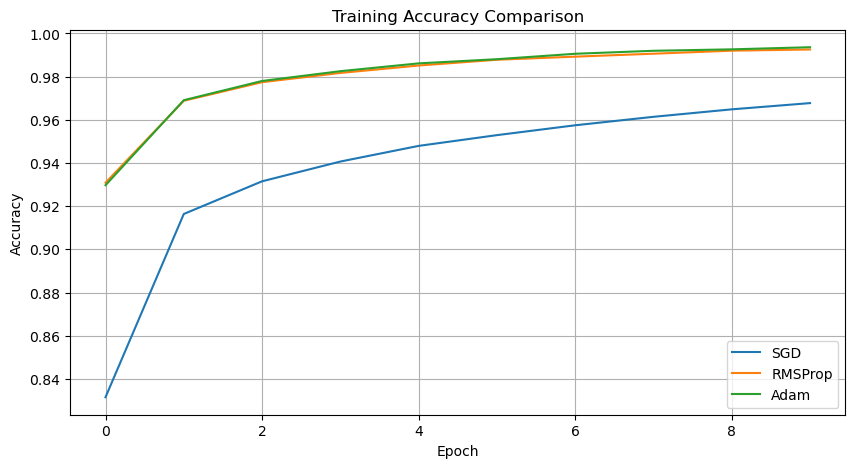

In [12]:
plt.figure(figsize=(10,5))

for name, history in histories.items():
    plt.plot(history.history['accuracy'], label=name)

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
print("\nFinal Comparison\n")

for name, history in histories.items():
    final_acc = history.history['accuracy'][-1]
    final_loss = history.history['loss'][-1]

    print(f"{name}")
    print(f"Accuracy : {final_acc:.4f}")
    print(f"Loss     : {final_loss:.4f}")
    print("-"*30)


Final Comparison

SGD
Accuracy : 0.9677
Loss     : 0.1113
------------------------------
RMSProp
Accuracy : 0.9926
Loss     : 0.0250
------------------------------
Adam
Accuracy : 0.9936
Loss     : 0.0190
------------------------------


In [ ]:
print("\nTesting Accuracy\n")

for name, optimizer in optimizers.items():

    model = create_model()

    # Create a completely fresh optimizer instance for each model
    # This ensures no state is shared between different model training sessions
    if name == 'Adam':
        fresh_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # Specify default parameters explicitly
    elif name == 'SGD':
        fresh_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
    elif name == 'RMSprop':
        fresh_optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    else:
        # For any other optimizer, create a new instance of the same type
        fresh_optimizer = type(optimizer)()
    
    model.compile(
        optimizer=fresh_optimizer,  # Use the fresh optimizer instance
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

    print(f"{name}")
    print(f"Test Accuracy = {accuracy:.4f}")
    print(f"Test Loss = {loss:.4f}")
    print()


Testing Accuracy

SGD
Test Accuracy = 0.9649
Test Loss = 0.1183

